# Predictive Maintenance: Machine Failure Prediction

## Project Overview

Unexpected machine failures can result in costly downtime, disrupted production and increased maintenance costs. This project explores machine operating data to identify patterns associated with equipment failure and develops machine-learning models to predict whether a machine is likely to fail.

The analysis combines **exploratory data analysis (EDA), data visualisation and machine learning** to investigate failure patterns and evaluate predictive performance.

### Project Objectives

- Explore the frequency and causes of machine failures.
- Investigate relationships between operating conditions and failure.
- Identify the machine characteristics most associated with failure predictions.
- Build classification models to predict machine failure.
- Compare Logistic Regression and Random Forest performance.
- Evaluate the trade-off between detecting failures and generating false maintenance alerts.

### Tools & Technologies

**Python | Pandas | NumPy | Matplotlib | Seaborn | Scikit-learn | Google Colab**

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2,3. Load the Dataset, data understanding and cleaning

In [2]:
df = pd.read_csv("ai4i2020.csv")
df.head()
df.shape
df.columns
df.info()
df.describe()

# print ("missing values:")
# print(df.isnull().sum())

# print ("\nDuplicate rows:")
# print(df.duplicated().sum())

# print ("\nData Types:")
# print (df.dtypes)

# print ("\nUnique Values:")
# print(df.nunique())

# print (df["Machine failure"].value_counts())

df  = df.rename(columns={
    "UDI" : "udi",
    "Product ID" : "product_id",
    "Type" : "type",
    "Air temperature [K]" : "air_temperature",
    "Process temperature [K]" : "process_temperature",
    "Rotational speed [rpm]" : "rotational_speed",
    "Torque [Nm]" : "torque",
    "Tool wear [min]" : "tool_wear",
    "Machine failure" : "machine_failure",
    "TWF" : "twf",
    "HDF" : "hdf",
    "PWF" : "pwf",
    "OSF" : "osf",
    "RNF" : "rnf"
})
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

Index(['udi', 'product_id', 'type', 'air_temperature', 'process_temperature',
       'rotational_speed', 'torque', 'tool_wear', 'machine_failure', 'twf',
       'hdf', 'pwf', 'osf', 'rnf'],
      dtype='object')

In [3]:
print (df["type"].value_counts())

type
L    6000
M    2997
H    1003
Name: count, dtype: int64


In [4]:
print("TWF:")
print(df["twf"].value_counts())

print("\nHDF:")
print(df["hdf"].value_counts())

print("\nPWF:")
print(df["pwf"].value_counts())

print("\nOSF:")
print(df["osf"].value_counts())

print("\nRNF:")
print(df["rnf"].value_counts())

TWF:
twf
0    9954
1      46
Name: count, dtype: int64

HDF:
hdf
0    9885
1     115
Name: count, dtype: int64

PWF:
pwf
0    9905
1      95
Name: count, dtype: int64

OSF:
osf
0    9902
1      98
Name: count, dtype: int64

RNF:
rnf
0    9981
1      19
Name: count, dtype: int64


## 4. Exploratory Data Analysis

### Analysis Approach

The exploratory analysis focuses on understanding the frequency of machine failures and identifying operating conditions that may help distinguish failed machines from normal operation.

The analysis investigates:

- The overall frequency of machine failure.
- The distribution of different failure types.
- Differences in operating conditions between failed and non-failed machines.
- Relationships between temperature, rotational speed, torque and tool wear.
- Correlations between operating variables and machine failure.

Because machine failures represent a relatively small proportion of the dataset, particular attention is given to **class imbalance**, as this can significantly affect how machine-learning model performance should be evaluated.

In [5]:
total_machines = len(df)

failed_machines = df["machine_failure"].sum()

non_failed_machines = total_machines - failed_machines

failure_rate = (failed_machines / total_machines) * 100

print("Total machines:", total_machines)
print("Failed machines:", failed_machines)
print("Non-failed machines:", non_failed_machines)
print("Failure rate:", round(failure_rate, 2), "%")

Total machines: 10000
Failed machines: 339
Non-failed machines: 9661
Failure rate: 3.39 %


In [6]:
failure_by_type = df.groupby("type")["machine_failure"].agg(
    total_machines="count",
    failed_machines="sum"
)

failure_by_type

failure_by_type["failure_rate"] = (
    failure_by_type["failed_machines"] /
    failure_by_type["total_machines"]
) * 100

failure_by_type["failure_rate"] = failure_by_type["failure_rate"].round(2)

failure_by_type

,total_machines,failed_machines,failure_rate
type,,,
H,1003,21,2.09
L,6000,235,3.92
M,2997,83,2.77


In [7]:
operating_conditions = df.groupby("machine_failure")[
    [
        "air_temperature",
        "process_temperature",
        "rotational_speed",
        "torque",
        "tool_wear"
    ]
].mean().round(2)

operating_conditions

,air_temperature,process_temperature,rotational_speed,torque,tool_wear
machine_failure,,,,,
0,299.97,310.00,1540.26,39.63,106.69
1,300.89,310.29,1496.49,50.17,143.78


## 5. Data Preparation for Machine Learning

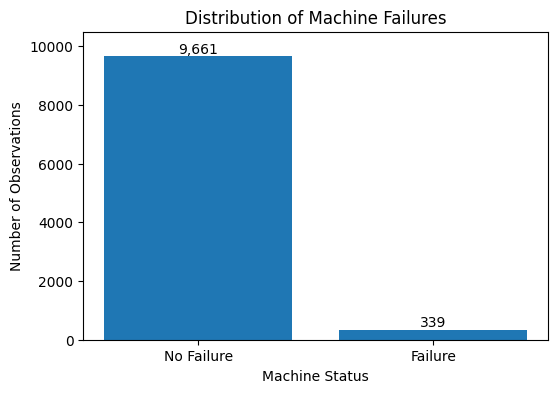

In [8]:
import matplotlib.pyplot as plt

failure_counts = df["machine_failure"].value_counts().sort_index()

plt.figure(figsize=(6, 4))

bars = plt.bar(
    ["No Failure", "Failure"],
    failure_counts.values
)

plt.title("Distribution of Machine Failures")
plt.xlabel("Machine Status")
plt.ylabel("Number of Observations")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.ylim(0, 10500)

plt.show()

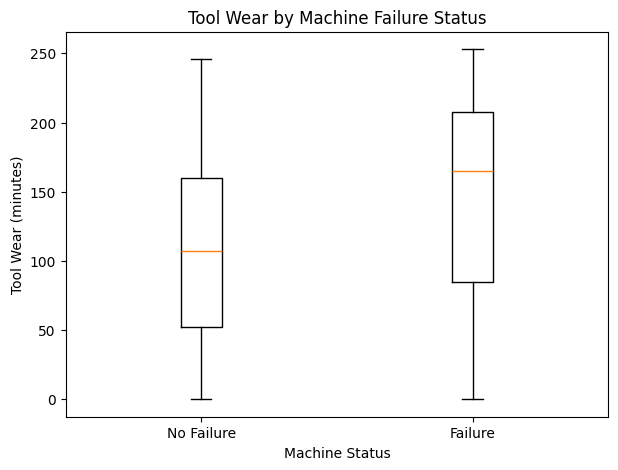

In [9]:
no_failure_tool_wear = df[df["machine_failure"] == 0]["tool_wear"]
failure_tool_wear = df[df["machine_failure"] == 1]["tool_wear"]

plt.figure(figsize=(7, 5))

plt.boxplot(
    [no_failure_tool_wear, failure_tool_wear],
    tick_labels=["No Failure", "Failure"]
)

plt.title("Tool Wear by Machine Failure Status")
plt.xlabel("Machine Status")
plt.ylabel("Tool Wear (minutes)")

plt.show()


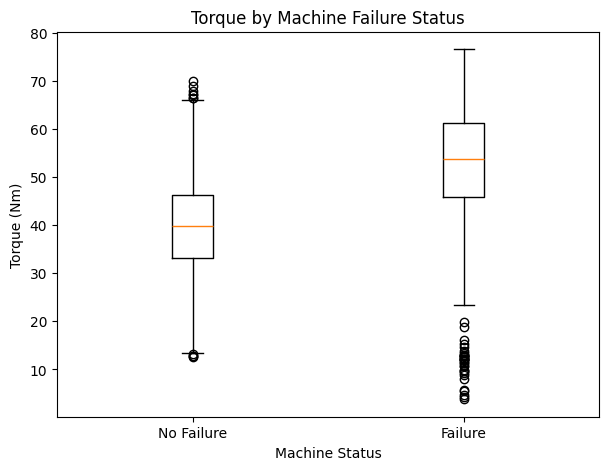

In [10]:
no_failure_torque = df[df["machine_failure"] == 0]["torque"]
failure_torque = df[df["machine_failure"] == 1]["torque"]

plt.figure(figsize=(7, 5))

plt.boxplot(
    [no_failure_torque, failure_torque],
    tick_labels=["No Failure", "Failure"]
)

plt.title("Torque by Machine Failure Status")
plt.xlabel("Machine Status")
plt.ylabel("Torque (Nm)")

plt.show()

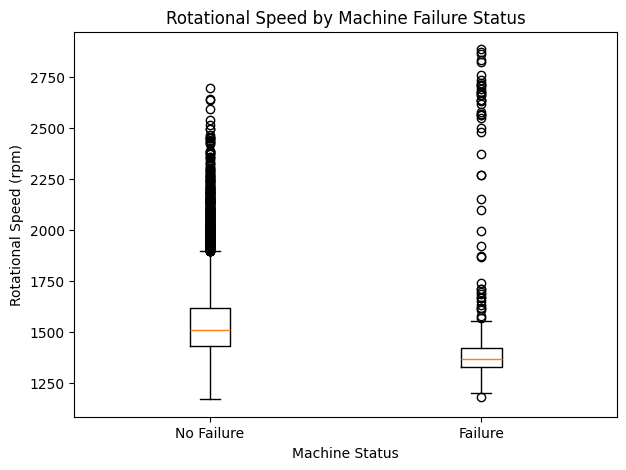

In [11]:
no_failure_speed = df[df["machine_failure"] == 0]["rotational_speed"]
failure_speed = df[df["machine_failure"] == 1]["rotational_speed"]

plt.figure(figsize=(7, 5))

plt.boxplot(
    [no_failure_speed, failure_speed],
    tick_labels=["No Failure", "Failure"]
)

plt.title("Rotational Speed by Machine Failure Status")
plt.xlabel("Machine Status")
plt.ylabel("Rotational Speed (rpm)")

plt.show()

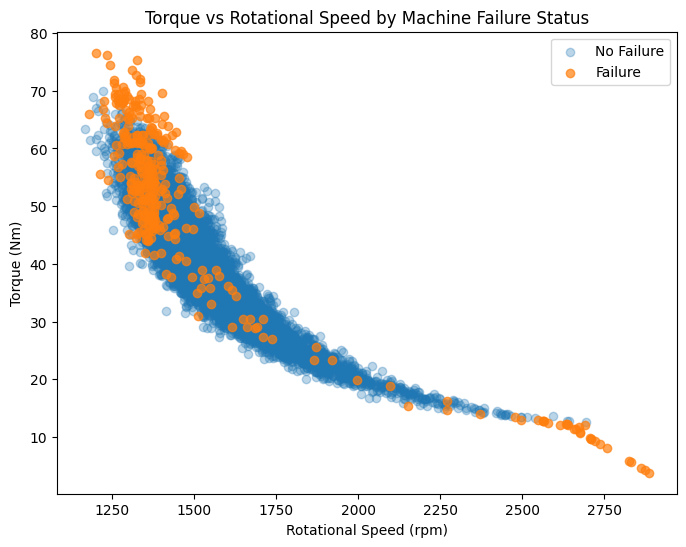

In [12]:
plt.figure(figsize=(8, 6))

no_failure = df[df["machine_failure"] == 0]
failure = df[df["machine_failure"] == 1]

plt.scatter(
    no_failure["rotational_speed"],
    no_failure["torque"],
    alpha=0.3,
    label="No Failure"
)

plt.scatter(
    failure["rotational_speed"],
    failure["torque"],
    alpha=0.7,
    label="Failure"
)

plt.title("Torque vs Rotational Speed by Machine Failure Status")
plt.xlabel("Rotational Speed (rpm)")
plt.ylabel("Torque (Nm)")
plt.legend()

plt.show()

In [13]:
failure_types = {
    "Tool Wear Failure": df["twf"].sum(),
    "Heat Dissipation Failure": df["hdf"].sum(),
    "Power Failure": df["pwf"].sum(),
    "Overstrain Failure": df["osf"].sum(),
    "Random Failure": df["rnf"].sum()
}

failure_types

{'Tool Wear Failure': np.int64(46),
 'Heat Dissipation Failure': np.int64(115),
 'Power Failure': np.int64(95),
 'Overstrain Failure': np.int64(98),
 'Random Failure': np.int64(19)}

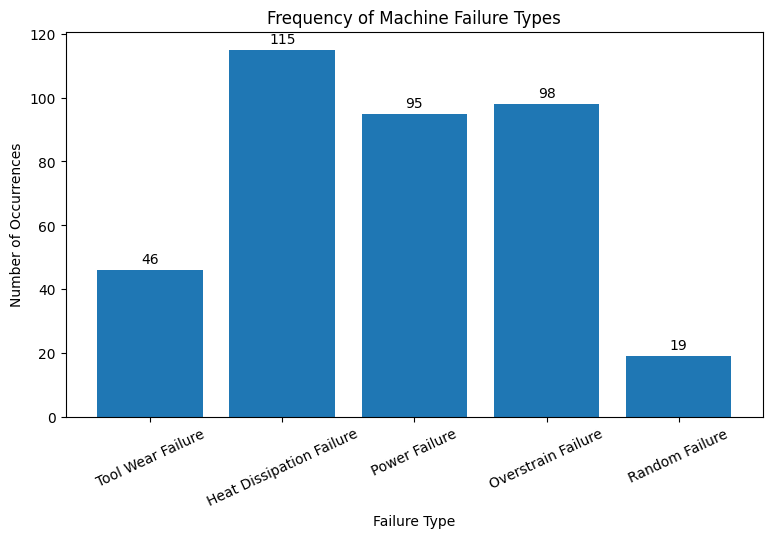

In [14]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    failure_types.keys(),
    failure_types.values()
)

plt.title("Frequency of Machine Failure Types")
plt.xlabel("Failure Type")
plt.ylabel("Number of Occurrences")
plt.xticks(rotation=25)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        int(bar.get_height()),
        ha="center"
    )

plt.show()

In [15]:
df["temperature_difference"] = (
    df["process_temperature"] - df["air_temperature"]
)

hdf_comparison = df.groupby("hdf")[
    [
        "air_temperature",
        "process_temperature",
        "temperature_difference",
        "rotational_speed",
        "torque"
    ]
].mean().round(2)

hdf_comparison

,air_temperature,process_temperature,temperature_difference,rotational_speed,torque
hdf,,,,,
0,299.98,310.00,10.02,1541.12,39.83
1,302.56,310.79,8.23,1337.26,53.17


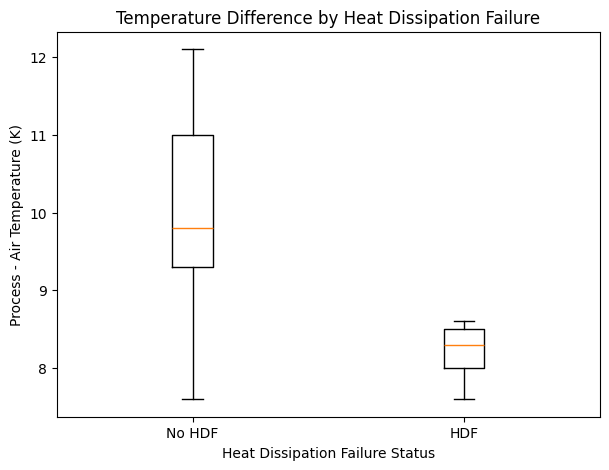

In [16]:
no_hdf = df[df["hdf"] == 0]["temperature_difference"]
hdf_failure = df[df["hdf"] == 1]["temperature_difference"]

plt.figure(figsize=(7, 5))

plt.boxplot(
    [no_hdf, hdf_failure],
    tick_labels=["No HDF", "HDF"]
)

plt.title("Temperature Difference by Heat Dissipation Failure")
plt.xlabel("Heat Dissipation Failure Status")
plt.ylabel("Process - Air Temperature (K)")

plt.show()

In [17]:
correlation_columns = [
    "air_temperature",
    "process_temperature",
    "temperature_difference",
    "rotational_speed",
    "torque",
    "tool_wear",
    "machine_failure"
]

correlation_matrix = df[correlation_columns].corr().round(2)

correlation_matrix

,air_temperature,process_temperature,temperature_difference,rotational_speed,torque,tool_wear,machine_failure
air_temperature,1.00,0.88,-0.70,0.02,-0.01,0.01,0.08
process_temperature,0.88,1.00,-0.27,0.02,-0.01,0.01,0.04
temperature_difference,-0.70,-0.27,1.00,-0.02,0.01,-0.01,-0.11
rotational_speed,0.02,0.02,-0.02,1.00,-0.88,0.00,-0.04
torque,-0.01,-0.01,0.01,-0.88,1.00,-0.00,0.19
tool_wear,0.01,0.01,-0.01,0.00,-0.00,1.00,0.11
machine_failure,0.08,0.04,-0.11,-0.04,0.19,0.11,1.00


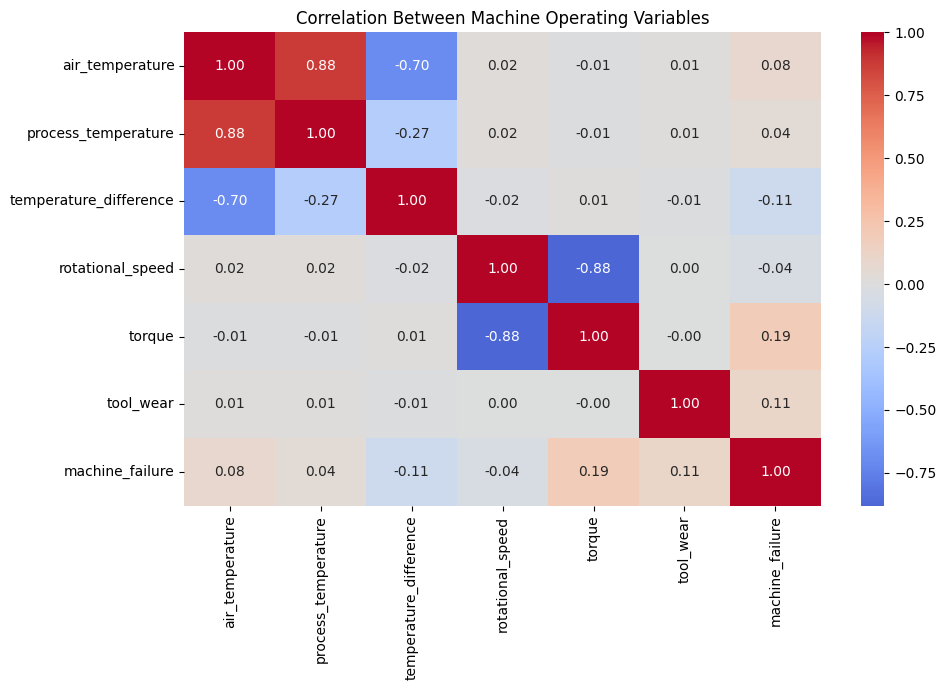

In [18]:
import seaborn as sns
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Machine Operating Variables")
plt.tight_layout()
plt.show()

In [19]:
features = [
    "type",
    "air_temperature",
    "process_temperature",
    "temperature_difference",
    "rotational_speed",
    "torque",
    "tool_wear"
]

X = df[features]
y = df["machine_failure"]

print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)

X.head()

Feature data shape: (10000, 7)
Target data shape: (10000,)


,type,air_temperature,process_temperature,temperature_difference,rotational_speed,torque,tool_wear
0,M,298.1,308.6,10.5,1551,42.8,0
1,L,298.2,308.7,10.5,1408,46.3,3
2,L,298.1,308.5,10.4,1498,49.4,5
3,L,298.2,308.6,10.4,1433,39.5,7
4,L,298.2,308.7,10.5,1408,40.0,9


In [20]:
X = pd.get_dummies(X, columns=["type"], drop_first=True, dtype=int)

X.head()

,air_temperature,process_temperature,temperature_difference,rotational_speed,torque,tool_wear,type_L,type_M
0,298.1,308.6,10.5,1551,42.8,0,0,1
1,298.2,308.7,10.5,1408,46.3,3,1,0
2,298.1,308.5,10.4,1498,49.4,5,1,0
3,298.2,308.6,10.4,1433,39.5,7,1,0
4,298.2,308.7,10.5,1408,40.0,9,1,0


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (8000, 8)
Testing features: (2000, 8)
Training target: (8000,)
Testing target: (2000,)


## 6. Logistic Regression Model

In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


## 7. Logistic Regression Evaluation

In [23]:
y_pred = model.predict(X_test)

print("First 20 actual values:")
print(y_test.values[:20])

print("\nFirst 20 predictions:")
print(y_pred[:20])

First 20 actual values:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]

First 20 predictions:
[1 0 1 0 1 1 1 0 0 1 0 0 0 0 0 1 0 1 0 0]


In [24]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Failure", "Failure"]
))

Confusion Matrix:
[[1599  333]
 [  12   56]]

Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      0.83      0.90      1932
     Failure       0.14      0.82      0.25        68

    accuracy                           0.83      2000
   macro avg       0.57      0.83      0.57      2000
weighted avg       0.96      0.83      0.88      2000



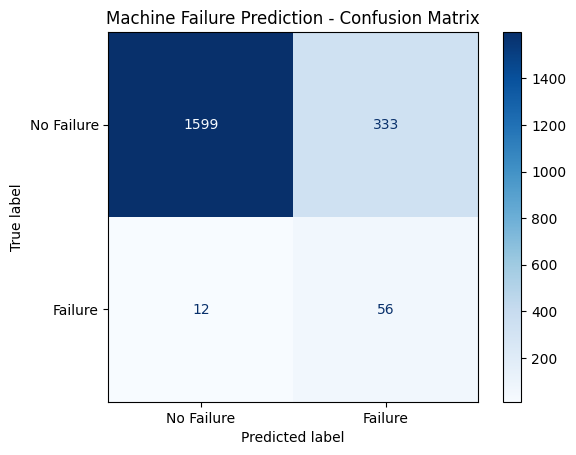

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Failure", "Failure"]
).plot(cmap="Blues")

plt.title("Machine Failure Prediction - Confusion Matrix")
plt.show()

In [26]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(roc_auc, 3))

ROC-AUC Score: 0.907


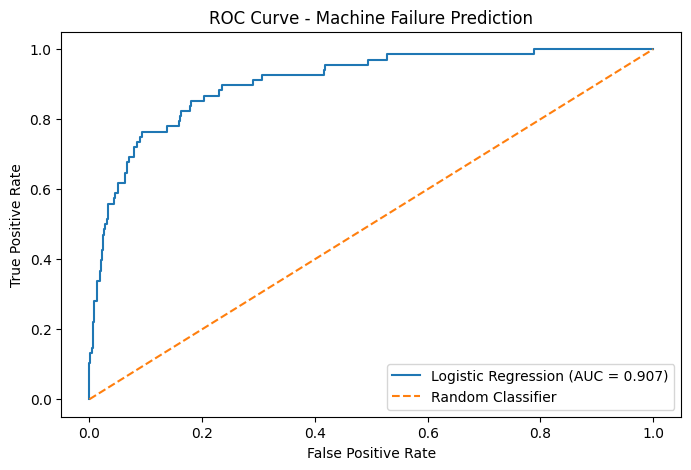

In [27]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Machine Failure Prediction")
plt.legend()

plt.show()

In [28]:
from sklearn.metrics import precision_score, recall_score

thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds_to_test:
    predictions = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)

    print(
        f"Threshold: {threshold} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f}"
    )

Threshold: 0.3 | Precision: 0.09 | Recall: 0.93
Threshold: 0.4 | Precision: 0.12 | Recall: 0.90
Threshold: 0.5 | Precision: 0.14 | Recall: 0.82
Threshold: 0.6 | Precision: 0.18 | Recall: 0.76
Threshold: 0.7 | Precision: 0.24 | Recall: 0.71


In [29]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_[0]
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient,Absolute_Coefficient
2,temperature_difference,-0.654719,0.654719
6,type_L,0.489552,0.489552
1,process_temperature,-0.356411,0.356411
0,air_temperature,0.298308,0.298308
4,torque,0.240084,0.240084
7,type_M,0.017635,0.017635
5,tool_wear,0.013617,0.013617
3,rotational_speed,0.009561,0.009561


## 8. Random Forest Model

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [31]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

rf_cm = confusion_matrix(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest Confusion Matrix:")
print(rf_cm)

print("\nRandom Forest Classification Report:")
print(classification_report(
    y_test,
    rf_pred,
    target_names=["No Failure", "Failure"]
))

print("Random Forest ROC-AUC:", round(rf_auc, 3))

Random Forest Confusion Matrix:
[[1930    2]
 [  25   43]]

Random Forest Classification Report:
              precision    recall  f1-score   support

  No Failure       0.99      1.00      0.99      1932
     Failure       0.96      0.63      0.76        68

    accuracy                           0.99      2000
   macro avg       0.97      0.82      0.88      2000
weighted avg       0.99      0.99      0.99      2000

Random Forest ROC-AUC: 0.968


## 9. Model Comparison

In [32]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "ROC-AUC": [roc_auc, rf_auc],
    "Failure Precision": [0.14, 0.96],
    "Failure Recall": [0.82, 0.63],
    "Failure F1-Score": [0.25, 0.76]
})

model_comparison.round(3)


,Model,ROC-AUC,Failure Precision,Failure Recall,Failure F1-Score
0,Logistic Regression,0.907,0.14,0.82,0.25
1,Random Forest,0.968,0.96,0.63,0.76


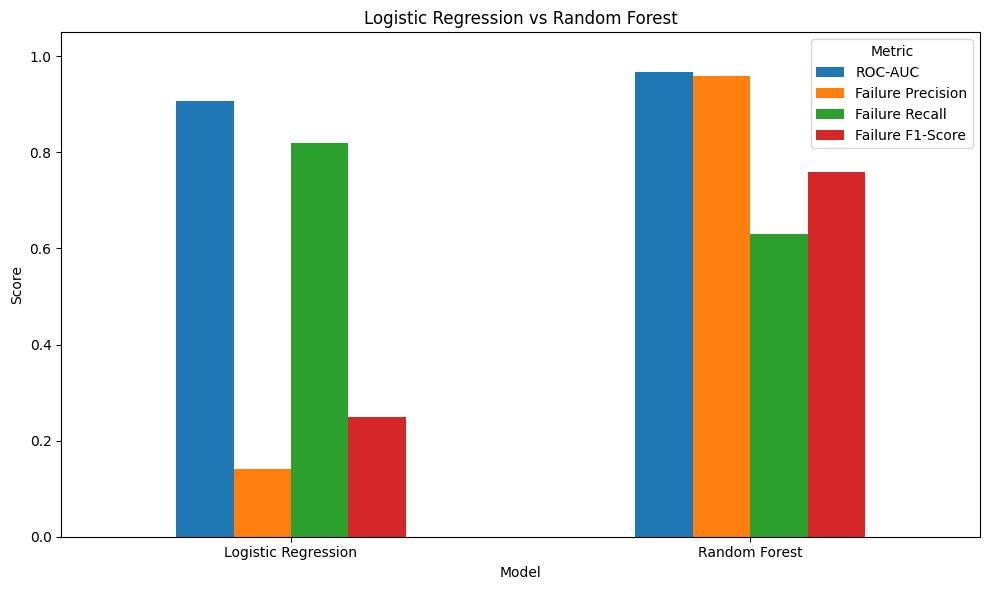

In [33]:
import matplotlib.pyplot as plt

metrics = ["ROC-AUC", "Failure Precision", "Failure Recall", "Failure F1-Score"]

model_comparison.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Logistic Regression vs Random Forest")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## 10. Feature Importance

In [34]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

rf_importance

,Feature,Importance
4,torque,0.322161
3,rotational_speed,0.244708
5,tool_wear,0.198558
2,temperature_difference,0.100606
0,air_temperature,0.064812
1,process_temperature,0.051032
6,type_L,0.010445
7,type_M,0.007678


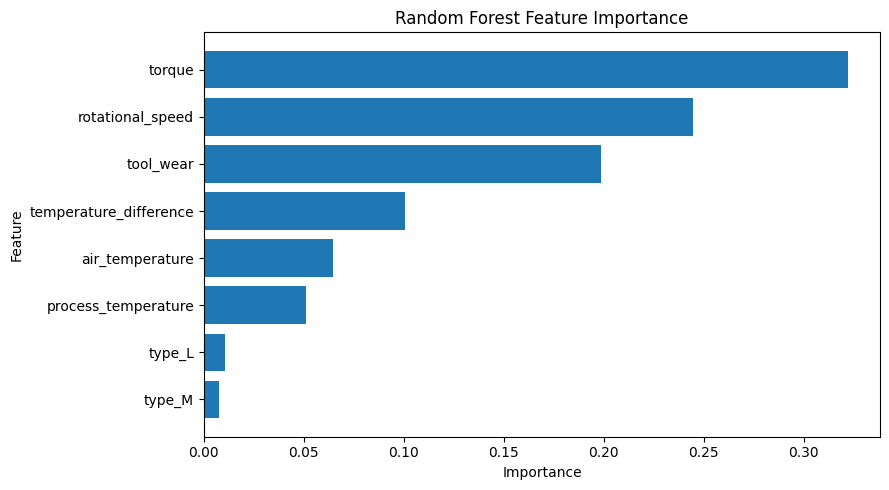

In [35]:
plt.figure(figsize=(9, 5))

plt.barh(
    rf_importance["Feature"],
    rf_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## 11. Conclusion & Business Recommendations

## Model Evaluation & Key Findings

Two classification models were evaluated for predicting machine failure: Logistic Regression and Random Forest.

### Model Performance

The Logistic Regression model achieved a ROC-AUC of **0.907** and detected **82% of machine failures**. However, its failure precision was only **14%**, resulting in a high number of false-positive maintenance alerts.

The Random Forest model achieved a higher ROC-AUC of **0.968** and a failure F1-score of **0.76**. It correctly identified **43 of the 68 failures** in the test set while producing only **2 false-positive failure predictions**. Its failure precision reached **96%**, although recall decreased to **63%**.

This demonstrates an important trade-off. Logistic Regression identifies a greater proportion of actual failures, while Random Forest provides substantially more precise failure predictions with far fewer false alarms.

### Key Predictive Features

Random Forest feature importance identified the strongest predictors as:

- Torque - 32.2%
- Rotational speed - 24.5%
- Tool wear - 19.9%
- Temperature difference - 10.1%

Together, torque, rotational speed and tool wear accounted for approximately **77% of the model's feature importance**.

These results indicate that operating conditions related to mechanical load, machine speed and accumulated wear contain substantial predictive information for identifying machine failures.

### Business Application

In a predictive-maintenance setting, model selection should reflect the cost of different errors. Missing a machine failure may lead to unplanned downtime or equipment damage, while excessive false-positive alerts may lead to unnecessary inspections and maintenance costs.

The classification threshold could therefore be adjusted according to the organisation's tolerance for missed failures versus false maintenance alerts.